## Lecture 9 - (10/03/2026)

Today's Topics:

- Simple Graph Metrics
- Assortative mixing
- Network Diagnostics

In [72]:
import networkx as nx
import matplotlib.pyplot as plt

### Simple Graph Metrics

Networks come in all different shapes and sizes. Some are quite simple while others are more complex. For this reason, knowing the right metrics is very important in order to better understand what is going on in the network.

#### Degree

The degree of a node is just the number of connections or edges it has. In a directed graph, we break it down into two parts: in-degree (edges coming in) and out-degree (edges going out). Usually, we look at this as a distribution, which comes from the degree sequence.

Knowing a network’s degree sequence (or a node’s degree) helps us understand how many connections each node has. In many networks—especially social ones—most nodes will have a degree around one, since they need at least one connection to be part of the network.

Node 0 has degree 3
Node 1 has degree 2
Node 2 has degree 3
Node 3 has degree 2


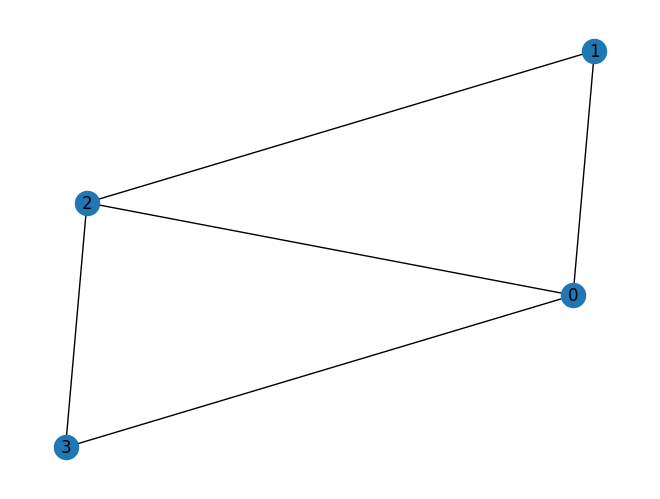

In [4]:
G = nx.path_graph(4)
G.add_edges_from([(0,3),(0,2)])
nx.draw(G, with_labels=True)

for i in range(4):
    print(f"Node {i} has degree {G.degree(i)}")

In [19]:
nx.to_pandas_adjacency(G)

,0,1,2,3
0,0.0,1.0,1.0,1.0
1,1.0,0.0,1.0,0.0
2,1.0,1.0,0.0,1.0
3,1.0,0.0,1.0,0.0


#### Density

Density (or clustering coefficient) is a handy metric for figuring out how clustered a network is. It’s basically the ratio of how many edges the network actually has compared to the total number of edges it could have if every node was connected to every other node.

This metric gives you a quick snapshot of how many edges are filled in the network. In big, complex networks, this number is usually pretty low. But in smaller, sparse networks, you often get a higher density because there’s a better chance that most of the possible edges are filled.

In [21]:
nx.density(G)

0.8333333333333334

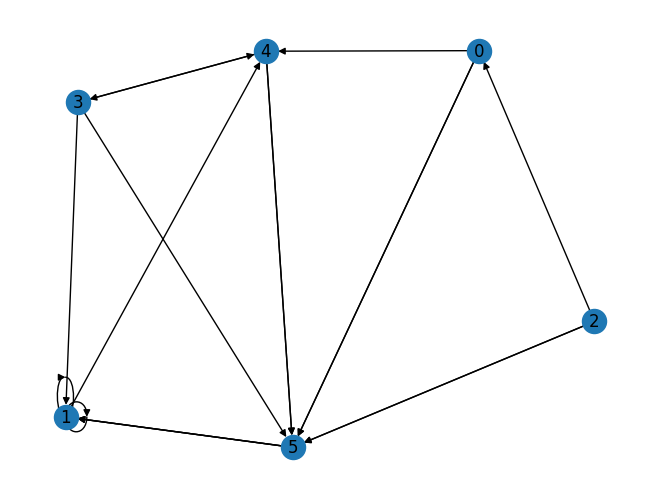

In [22]:
# https://networkx.org/documentation/stable/reference/generated/networkx.generators.directed.gnr_graph.html#networkx.generators.directed.gnr_graph
""
H = nx.random_k_out_graph(6, 3, alpha=1)
nx.draw(H, with_labels=True)

In [23]:
nx.density(H)

0.6

In [24]:
nx.to_pandas_adjacency(H)

,0,1,2,3,4,5
0,0.0,0.0,0.0,0.0,1.0,2.0
1,0.0,2.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,2.0
3,0.0,1.0,0.0,0.0,1.0,1.0
4,0.0,0.0,0.0,1.0,0.0,2.0
5,0.0,3.0,0.0,0.0,0.0,0.0


#### Reciprocity

In social network analysis, one useful way to spot meaningful connections is by looking at reciprocity. This only applies to directed networks because we’re talking about ties that go both ways—edges that point in both directions between two nodes.

Why should you care about reciprocity?

Reciprocity is a big deal when it comes to understanding how people interact. Think of it like this: in a social setting, a reciprocated edge might show that one user is replying to another or returning a favour. This can hint that these users prefer to engage with each other more than with others.

With NetworkX, you can measure this easily using a built-in function that gives you a value representing the proportion of reciprocated edges to the total number of edges in the network. The higher the value, the more back-and-forth ties there are. For example, reciprocity is calculated with the following.

In [25]:
nx.reciprocity(H)

0.1111111111111111

#### Transitivity

In network analysis, a triad (basically a group of three nodes) is seen as one of the key building blocks of any network. Transitivity is like the likelihood that connected nodes are all linked together within the network.

It helps show how complete a network is. For example, social interactions like indirect reciprocity (think "the enemy of my enemy is my friend") depend on triads—where three people or entities are involved. Similar to density, transitivity gives a good sense of how interconnected the whole network is.

In [37]:
nx.transitivity(G)

0.75

![image](../attachments/densityvstransivity.png)

#### Eigenvector centrality

Eigenvector centrality is another diagnostic that considers non-direct connections. If node degree measures the number of connections of a node, eigenvector centrality measures the extent to which those connected to a node are themselves highly connected nodes. Eigenvector centrality is an indicator of the influence of a node in a network. People with high eigenvector centrality in social and information networks are influential because they are connected to others who are themselves highly connected and, thus, can easily reach many other people in the networks.

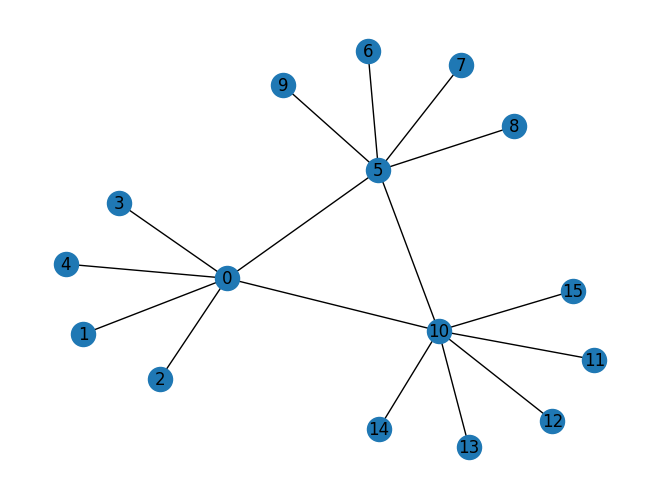

In [5]:
D1, D2, D3 = nx.star_graph(5), nx.star_graph(5), nx.star_graph(5)

D2 = nx.relabel_nodes(D2, lambda x : x + 5)
D3 = nx.relabel_nodes(D3, lambda x : x + 10)

D = nx.compose_all([D1, D2, D3])

D.add_edges_from([(0,5),(5,10),(0,10)])

nx.draw(D, with_labels=True)

In [7]:
nx.eigenvector_centrality(D)

{0: 0.4707165996958812,
 1: 0.14202248562291092,
 2: 0.14202248562291092,
 3: 0.14202248562291092,
 4: 0.14202248562291092,
 5: 0.4707165996958811,
 6: 0.14202248562291092,
 7: 0.14202248562291092,
 8: 0.14202248562291092,
 9: 0.14202248562291092,
 10: 0.5213296685683192,
 11: 0.15729211730526232,
 12: 0.15729211730526232,
 13: 0.15729211730526232,
 14: 0.15729211730526232,
 15: 0.15729211730526232}

## Assortative mixing

Assortativity or assortative mixing (also called homophily) is the preference of nodes with similar attributes to interact between each other. In other words, "[similarity breeds connection](https://www.annualreviews.org/content/journals/10.1146/annurev.soc.27.1.415)" McPherson et al. To illustrate the tendency for assortative mixing, we first add node attributes.

In [ ]:
G.clear()
G.add_nodes_from([1,2,3,4,5,6])

In [30]:
G.nodes[1]["gender"] = "female"
G.nodes[2]["gender"] = "female"
G.nodes[3]["gender"] = "male"
G.nodes[4]["gender"] = "male"
G.nodes[5]["gender"] = "female"
G.nodes[6]["gender"] = "female"

In [31]:
nodes_colors = []
for node in G.nodes:
    if G.nodes[node]["gender"] == "female":
        nodes_colors.append("#40E0D0")
    else:
        nodes_colors.append("#E6E6FA")

In [32]:
nodes_colors

['#40E0D0', '#40E0D0', '#E6E6FA', '#E6E6FA', '#40E0D0', '#40E0D0']

In [34]:
G.add_edges_from([(1,2), (2,5), (1,6), (5,6), (1,4), (2,4), (4,3)])

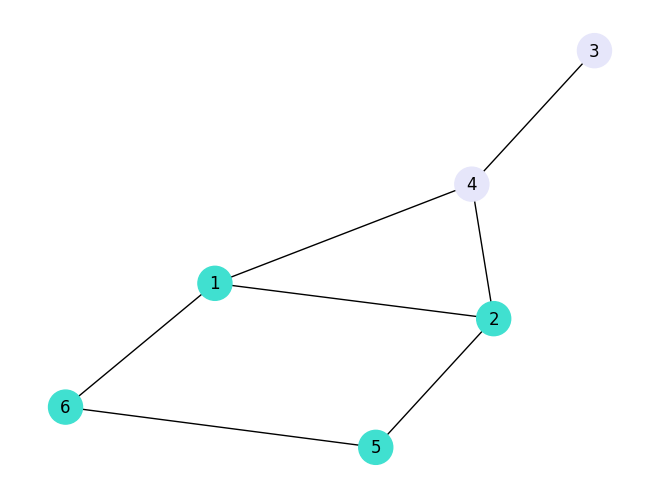

In [35]:
nx.draw(G, with_labels=True, node_color=nodes_colors, node_size=600)

#### Measuring assortativity

Let’s see if indeed similarity with respect to gender attributes breeds connections in our toy network. Networks in which similar nodes are more likely to connect than dissimilar nodes are called assortative.

In [36]:
nx.attribute_assortativity_coefficient(G, attribute="gender")

0.29999999999999993

Nodes may be linked because they have similar social attributes but also because they have similar number of links or a similar role in a network. Let’s see if nodes with similar node degree are more likely (i.e., degree assortativity) or less likely (i.e., degree disassortativity) to be linked in our example network.

In [37]:
nx.degree_assortativity_coefficient(G)

-0.10526315789473463

#### The Matrix Movie Network

Each node in the The Matrix network represents a character and each edge represents the number of times a pair of characters appeared together in a scene of the movie. Edges are undirected and weighted.

In [58]:
import requests
import json
import pandas as pd

url = "https://moviegalaxies.com/movies/view/543/the-matrix/download"

response = requests.get(url)
data = json.loads(response.text)

data['network'].keys()

dict_keys(['edges', 'nodes', 'positions'])

In [62]:
edges = data['network']['edges']
nodes = data['network']['nodes']
positions = data['network']['positions']

In [63]:
matrix_graph = nx.Graph()

matrix_graph.add_nodes_from((node['name'], node) for node in nodes)
matrix_graph.add_edges_from((edge['source'], edge['target'], edge) for edge in edges)
pos = {p['name']: (p['x'], p['y']) for p in positions}

In [68]:
matrix_graph['NEO']['MORPHEUS']

{'source': 'NEO', 'target': 'MORPHEUS', 'weight': 10}

{('LIEUTENANT',
  'AGENT SMITH'): Text(-0.3726796827030869, -0.032576674956118046, '1'),
 ('MOUSE', 'CYPHER'): Text(-0.11488986517371191, 0.1267906141650328, '1'),
 ('MOUSE', 'TRINITY'): Text(-0.062399302554665415, 0.13044975219388355, '1'),
 ('MOUSE', 'APOC'): Text(-0.15589147792636848, 0.17555877261092367, '1'),
 ('MOUSE', 'NEO'): Text(-0.07779887798430918, 0.07430795538469426, '1'),
 ('MOUSE', 'CABLE'): Text(-0.11668260644664852, 0.22410774225183883, '3'),
 ('MOUSE', 'SWITCH'): Text(-0.19648339890814348, 0.1760629139453429, '1'),
 ('MOUSE', 'MORPHEUS'): Text(-0.055803523462361615, 0.1607714191348062, '1'),
 ('MOUSE', 'TANK'): Text(-0.11234200831115715, 0.15969756629271947, '4'),
 ('APOC', 'CYPHER'): Text(-0.12155852760955921, 0.08897600223016178, '2'),
 ('APOC', 'TRINITY'): Text(-0.06906645951901957, 0.09263367603151706, '2'),
 ('APOC', 'MORPHEUS'): Text(-0.06247381987428757, 0.12295750666069027, '1'),
 ('APOC', 'NEO'): Text(-0.08446872457035393, 0.03649509520127625, '1'),
 ('APOC',

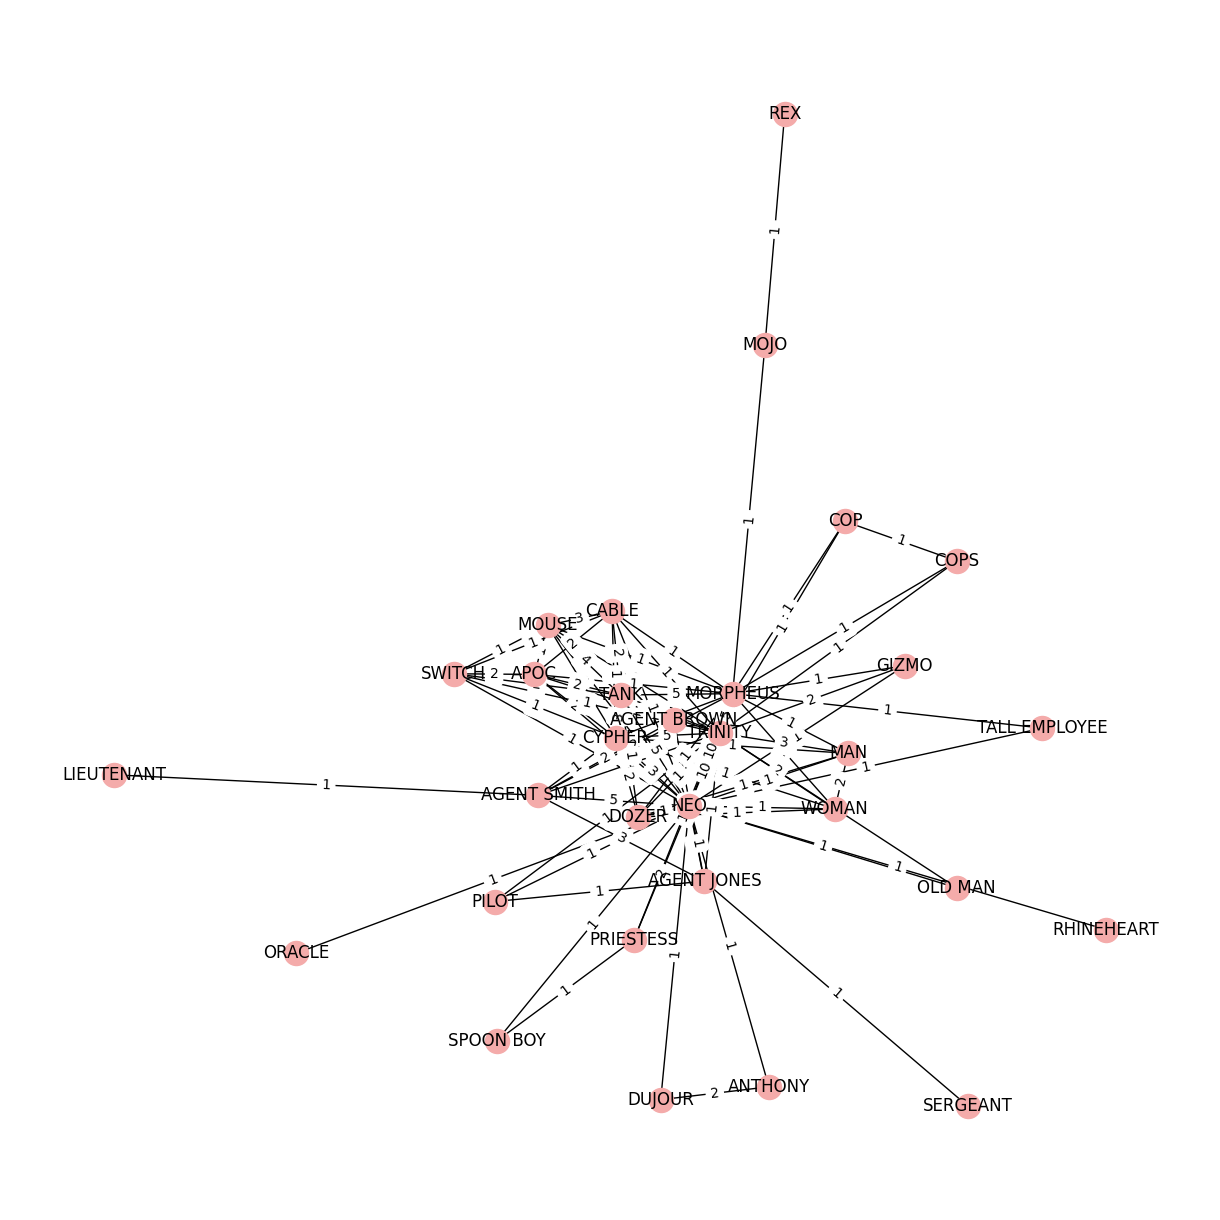

In [73]:
plt.figure(figsize=(12,12))

node_position = nx.spring_layout(matrix_graph)
nx.draw(matrix_graph, node_position, node_color="#F4ABAA", with_labels=True)
edge_labels = nx.get_edge_attributes(matrix_graph, "weight")
nx.draw_networkx_edge_labels(matrix_graph, node_position, edge_labels=edge_labels)

In [74]:
nx.average_shortest_path_length(matrix_graph)

2.0795698924731183

In [75]:
nx.algorithms.distance_measures.diameter(matrix_graph)

5

## Network Diagnostics

To study the meso-scale properties of a network, we identify network communities. Network communities are collection of nodes that are more connected to each other than to other communities compared to a null model. Many community detection methods have been developed to identify community structure in networks. To identify network communities in the The Matrix network, we will use a technique called modularity maximisation. We will maximise modularity using the Louvain community detection heuristics.

In [77]:
import community as community_louvain

In [78]:
# Detect the community structure of the graph which
# maximises the modularity using the Louvain heuristices.
partition = community_louvain.best_partition(matrix_graph, resolution=1)

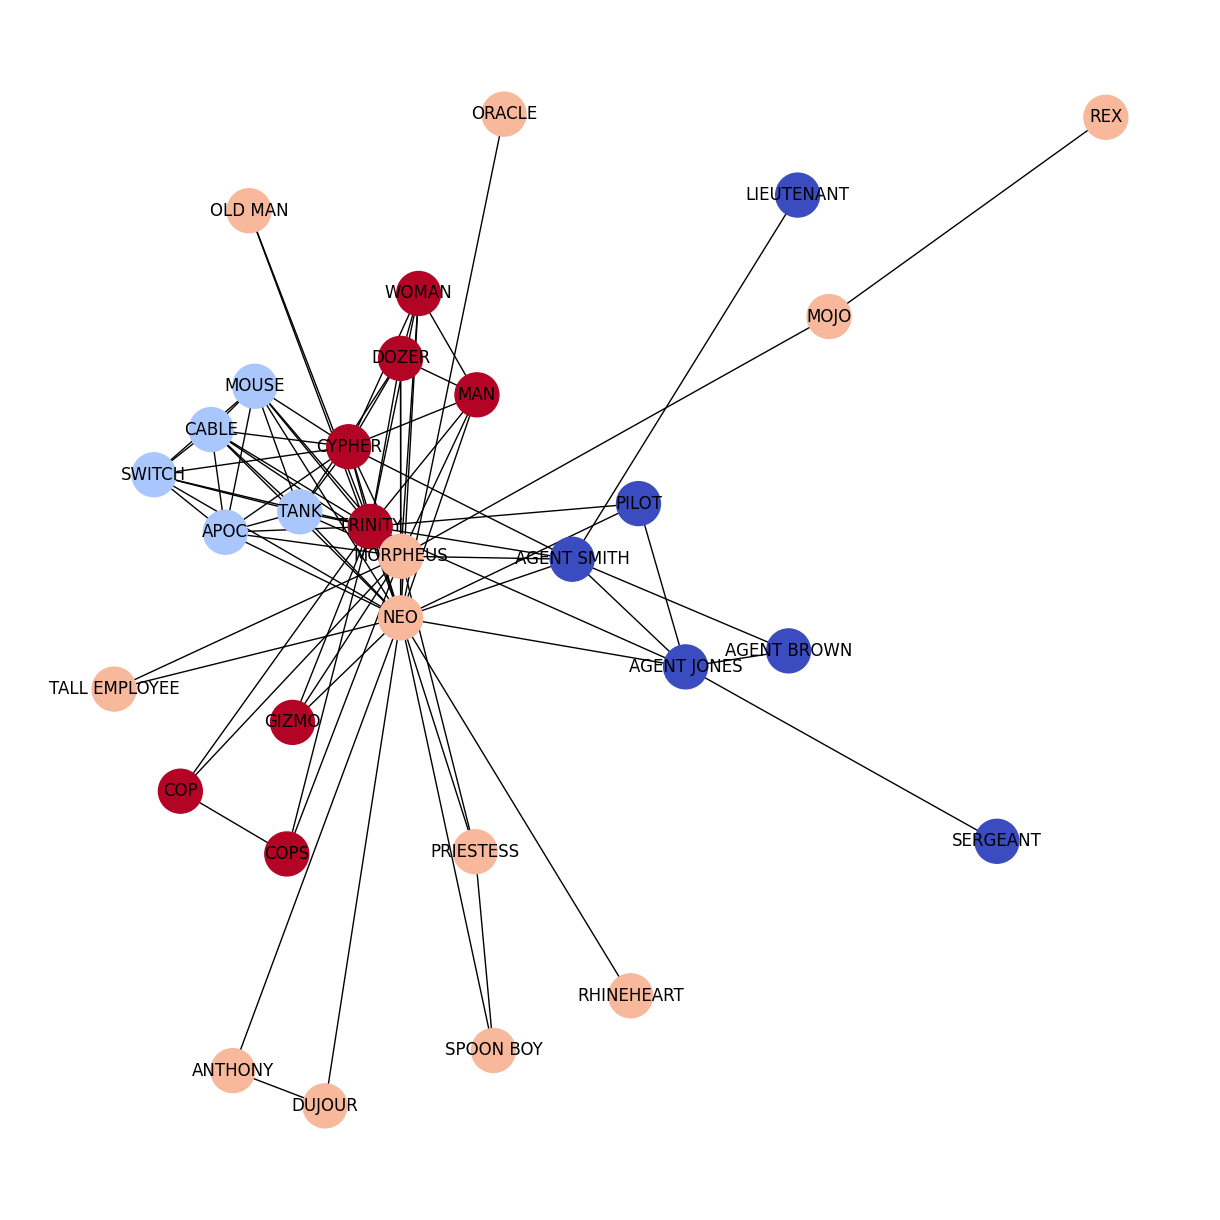

In [79]:
plt.figure(figsize=(12, 12))

nx.draw(
    matrix_graph,
    with_labels=True,
    pos=nx.spring_layout(matrix_graph),  # spring_layout is the default layout
    node_color=list(partition.values()),
    cmap=plt.cm.coolwarm,
    node_size=1000,
)

In [81]:
matrix_graph_degrees = nx.degree(matrix_graph)
sorted(matrix_graph_degrees, key=lambda x: x[1], reverse=True)

[('NEO', 23),
 ('TRINITY', 18),
 ('MORPHEUS', 17),
 ('CYPHER', 12),
 ('TANK', 9),
 ('MOUSE', 8),
 ('APOC', 8),
 ('CABLE', 8),
 ('AGENT SMITH', 7),
 ('DOZER', 7),
 ('SWITCH', 7),
 ('WOMAN', 6),
 ('AGENT JONES', 6),
 ('MAN', 6),
 ('COPS', 3),
 ('GIZMO', 3),
 ('PRIESTESS', 3),
 ('PILOT', 3),
 ('COP', 3),
 ('MOJO', 2),
 ('TALL EMPLOYEE', 2),
 ('SPOON BOY', 2),
 ('OLD MAN', 2),
 ('AGENT BROWN', 2),
 ('DUJOUR', 2),
 ('ANTHONY', 2),
 ('LIEUTENANT', 1),
 ('ORACLE', 1),
 ('REX', 1),
 ('SERGEANT', 1),
 ('RHINEHEART', 1)]

Text(0.5, 1.0, 'Movie: The Matrix network')

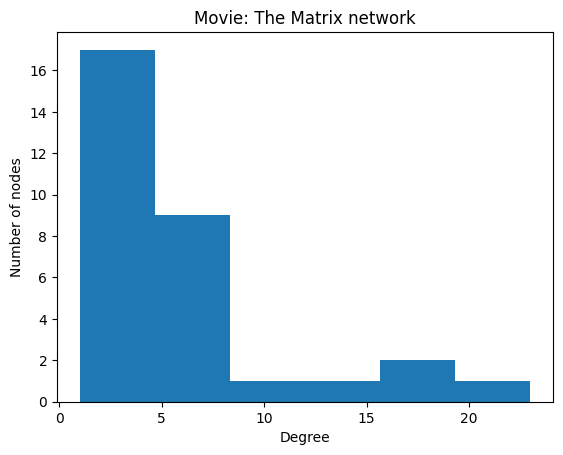

In [82]:
degree_values = dict(matrix_graph_degrees).values()

plt.hist(degree_values, 6)
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title("Movie: The Matrix network")

In [83]:
matrix_weights = nx.degree(matrix_graph, weight="weight")
sorted(matrix_weights, key=lambda x: x[1], reverse=True)

[('NEO', 52),
 ('TRINITY', 46),
 ('MORPHEUS', 36),
 ('TANK', 31),
 ('CYPHER', 23),
 ('AGENT SMITH', 15),
 ('MOUSE', 13),
 ('APOC', 13),
 ('CABLE', 12),
 ('AGENT JONES', 10),
 ('MAN', 9),
 ('SWITCH', 9),
 ('DOZER', 8),
 ('WOMAN', 8),
 ('AGENT BROWN', 5),
 ('GIZMO', 4),
 ('PRIESTESS', 4),
 ('COPS', 3),
 ('DUJOUR', 3),
 ('ANTHONY', 3),
 ('PILOT', 3),
 ('COP', 3),
 ('MOJO', 2),
 ('TALL EMPLOYEE', 2),
 ('SPOON BOY', 2),
 ('OLD MAN', 2),
 ('LIEUTENANT', 1),
 ('ORACLE', 1),
 ('REX', 1),
 ('SERGEANT', 1),
 ('RHINEHEART', 1)]

In [84]:
nx.shortest_path_length(matrix_graph, "NEO")

{'NEO': 0,
 'MOUSE': 1,
 'APOC': 1,
 'ORACLE': 1,
 'AGENT SMITH': 1,
 'DOZER': 1,
 'CABLE': 1,
 'TALL EMPLOYEE': 1,
 'WOMAN': 1,
 'CYPHER': 1,
 'TRINITY': 1,
 'SPOON BOY': 1,
 'TANK': 1,
 'OLD MAN': 1,
 'RHINEHEART': 1,
 'AGENT JONES': 1,
 'GIZMO': 1,
 'MAN': 1,
 'SWITCH': 1,
 'DUJOUR': 1,
 'ANTHONY': 1,
 'PRIESTESS': 1,
 'MORPHEUS': 1,
 'PILOT': 1,
 'LIEUTENANT': 2,
 'AGENT BROWN': 2,
 'COPS': 2,
 'COP': 2,
 'SERGEANT': 2,
 'MOJO': 2,
 'REX': 3}

[Matrix Graph](https://moviegalaxies.com/movies/view/543/the-matrix/#) from moviegalaxy